   지역        총인구         병원수
0  대구   200000.0   96.666667
1  부산   300000.0   80.000000
2  서울  1000000.0  150.000000
3  인천   500000.0   60.000000


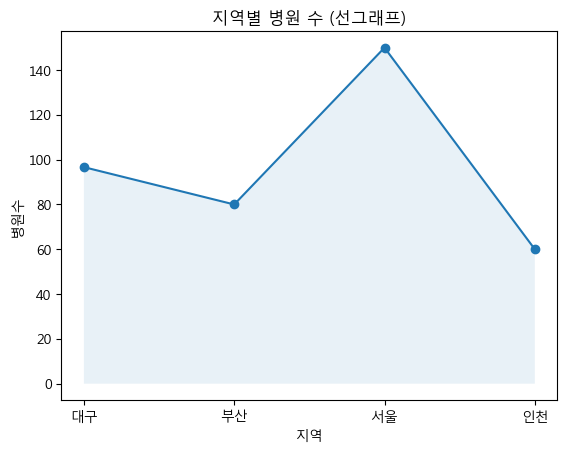

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 1. 데이터 생성
# ---------------------------
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [1000000, 300000, 200000]
})

df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150, 80, 60]
})

# ---------------------------
# 2. 데이터 병합 (지역 기준)
# how='outer' → 모든 지역 포함
# ---------------------------
merged= pd.merge(df1, df2, on="지역", how="outer")

# ---------------------------
# 3. 결측치 처리
# 총인구가 없는 값 → 평균으로 채우기
# ---------------------------
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged['병원수'] = merged['병원수'].fillna(merged['병원수'].mean())
# 결과 확인
print(merged)

# ---------------------------
# 4. 한글 깨짐 방지 설정
# ---------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.plot(merged["지역"], merged["병원수"], marker='o')

# 이 줄 추가 (영역 채우기)
plt.fill_between(merged["지역"], merged["병원수"], alpha=0.1)

plt.title("지역별 병원 수 (선그래프)")
plt.xlabel("지역")
plt.ylabel("병원수")

plt.show()


   지역        총인구         병원수
0  대구   200000.0   96.666667
1  부산   300000.0   80.000000
2  서울  1000000.0  150.000000
3  인천   500000.0   60.000000


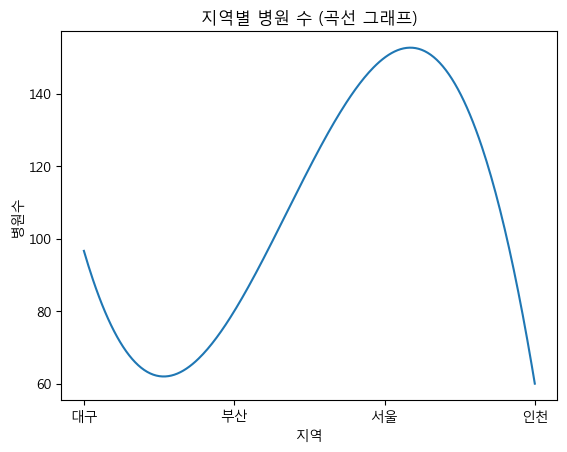

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# ---------------------------
# 1. 데이터 생성
# ---------------------------
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [1000000, 300000, 200000]
})

df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150, 80, 60]
})

# ---------------------------
# 2. 데이터 병합 (지역 기준)
# how='outer' → 모든 지역 포함
# ---------------------------
merged= pd.merge(df1, df2, on="지역", how="outer")

# ---------------------------
# 3. 결측치 처리
# 총인구가 없는 값 → 평균으로 채우기
# ---------------------------
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged['병원수'] = merged['병원수'].fillna(merged['병원수'].mean())
# 결과 확인
print(merged)

# ---------------------------
# 4. 한글 깨짐 방지 설정
# ---------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. x를 숫자로 변환
x = np.arange(len(merged["지역"]))
y = merged["병원수"]

# 2. 부드러운 곡선용 데이터 생성
x_smooth = np.linspace(x.min(), x.max(), 300)
y_smooth = make_interp_spline(x, y)(x_smooth)

# 3. 곡선 그래프
plt.plot(x_smooth, y_smooth)

#4. x축을 다시 지역 이름으로 표시
plt.xticks(x, merged["지역"])

plt.title("지역별 병원 수 (곡선 그래프)")
plt.xlabel("지역")
plt.ylabel("병원수")

plt.show()


   지역        총인구         병원수
0  대구   200000.0   96.666667
1  부산   300000.0   80.000000
2  서울  1000000.0  150.000000
3  인천   500000.0   60.000000
96.66666666666667
80.0
150.0
60.0


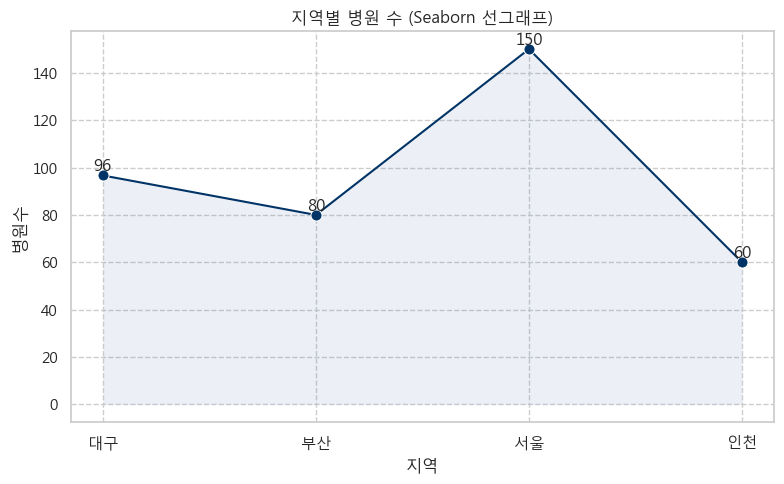

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# 1. 데이터 생성
# ---------------------------
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [1000000, 300000, 200000]
})

df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150, 80, 60]
})

# ---------------------------
# 2. 데이터 병합
# ---------------------------
merged = pd.merge(df1, df2, on="지역", how="outer")

# ---------------------------
# 3. 결측치 처리
# ---------------------------
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged["병원수"] = merged["병원수"].fillna(merged["병원수"].mean())

print(merged)

# ---------------------------
# 4. Seaborn 스타일 + 한글 설정
# ---------------------------
sns.set_style('whitegrid')   # 배경 스타일 설정
sns.set_palette('deep')    # 색상 스타일 설정

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------
# 5. 그래프 크기
# ---------------------------
plt.figure(figsize=(8, 5))

# ---------------------------
# 6. Seaborn 선그래프
# ---------------------------
ax = sns.lineplot(
    x="지역",
    y="병원수",
    data=merged,
    marker='o',
    markersize=8,   # 여기서 크기 조절
    color='#003366'   # 진한 파랑
)
plt.grid(linestyle='--')

# ---------------------------
# 7. 영역 채우기 (Matplotlib 활용)
# ---------------------------
plt.fill_between(
    merged["지역"],
    merged["병원수"],
    alpha=0.1,
)

for i in range(len(merged["병원수"])):
    v = merged["병원수"][i]  # i번째 병원수 값
    print(v)
    ax.text(
        i,        # x 위치 (막대의 위치: 0, 1, 2, 3 ...)
        v,        # y 위치 (막대 높이)
        int(v),   # 표시할 값
        ha='center',  # 가운데 정렬
        va='bottom'   # 막대 위쪽에 표시
    )

plt.title("지역별 병원 수 (Seaborn 선그래프)")
plt.xlabel("지역")
plt.ylabel("병원수")

# 여백 자동 조정
plt.tight_layout()

plt.show()